In [1]:
import dask
from dask import delayed
from dask.distributed import Client
from dask_jobqueue import SLURMCluster
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Change working directory
import os
os.chdir(os.getcwd() + "/../")
print(os.getcwd())

import config
from visualisation.plotting import coupled_label_plot

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation


## Load NEMI data

In [2]:
nemi_dfs = []
for file in Path(config.output_dir_nemi).glob("volume_nemi_iteration*.csv"):
    temp = pd.read_csv(file)
    temp["iteration"] = int(str(file).split("_")[-1].lstrip("iteration").rstrip(".csv"))
    nemi_dfs.append(temp)

In [8]:
nemi_dfs = pd.concat(nemi_dfs)

## Analyse NEMI uncertainties
Choose final cluster set as the run with lowest mean uncertainty

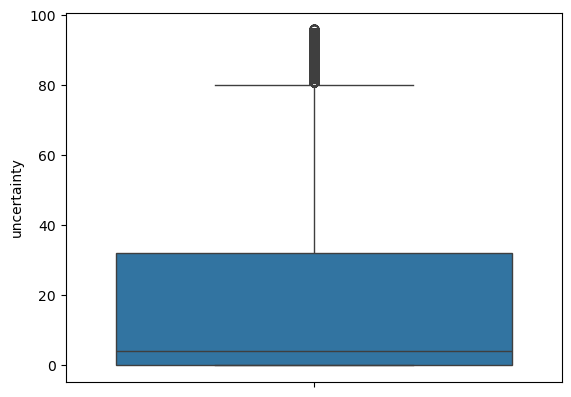

In [9]:
# Uncertainties across all ensemble members
sns.boxplot(nemi_dfs["uncertainty"])
plt.show()

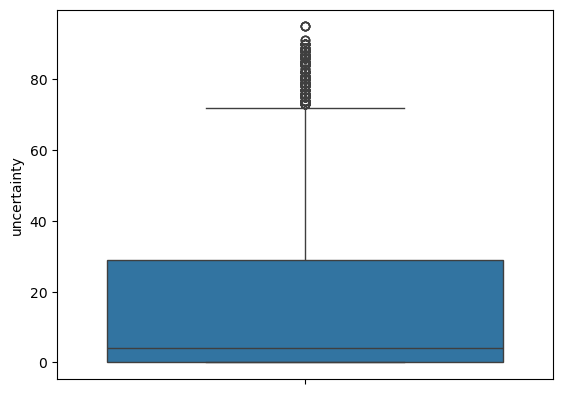

Base id 34.0 has the lowest mean uncertainty across the ensemble (15.52 +- 19.8%)


In [41]:
# Uncertainties of ensemble member with lowest uncertainty
uncertainty_per_member = nemi_dfs[["iteration", "uncertainty"]].groupby("iteration").mean().reset_index()
final_cluster_id = uncertainty_per_member[uncertainty_per_member["uncertainty"] == uncertainty_per_member["uncertainty"].min()].iloc[0]["iteration"]
final_df = nemi_dfs[nemi_dfs["iteration"] == final_cluster_id]

sns.boxplot(final_df["uncertainty"])
plt.show()

print(f"Base id {final_cluster_id} has the lowest mean uncertainty across the ensemble ({np.round(final_df.uncertainty.mean(), 2)} +- {np.round(final_df.uncertainty.std(), 1)}%)")

In [43]:
uncertainty_per_member.sort_values("uncertainty")

,iteration,uncertainty
34,34,15.515623
86,86,15.536223
18,18,15.542137
78,78,15.563410
88,88,15.568672
...,...,...
7,7,19.065980
27,27,20.238018
56,56,20.507138
98,98,21.383867


## Final cluster set

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


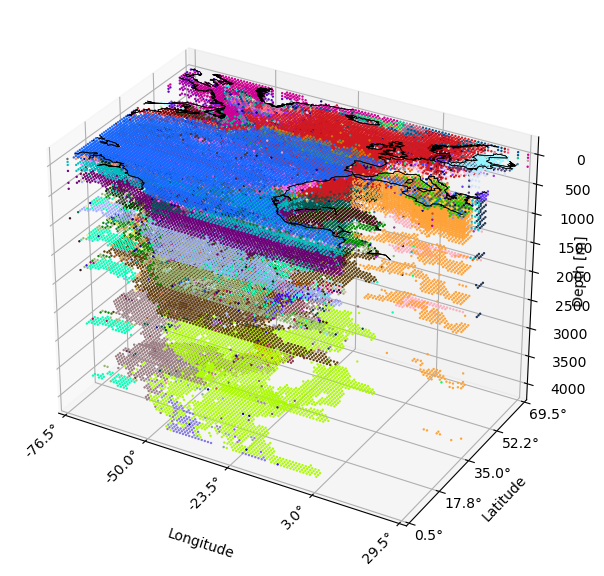

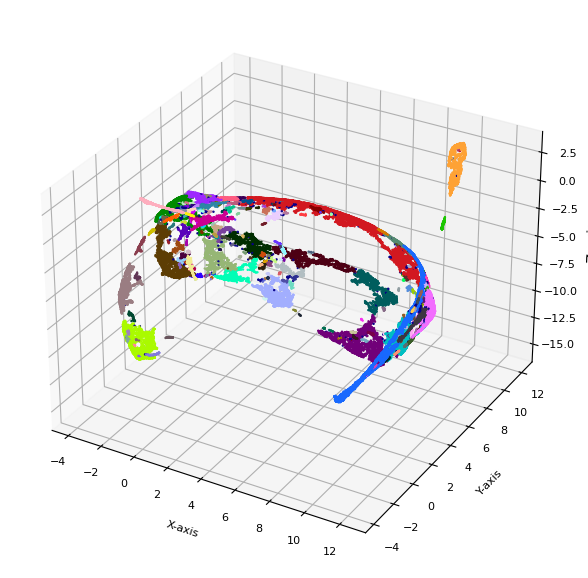

In [42]:
coupled_label_plot(final_df[final_df.label != 0], color_label="label_color", save_dir=None, suffix="", save_as=None, figsize=(6, 6),
                       fontsize=8, ticklabelsize=8,
                       adjust_left=0, adjust_right=0.92, adjust_top=1.1, adjust_bottom=-0.05, pointsize=0.5, dpi=1000,
                       xlabelpad=20, ylabelpad=0, zlabelpad=0)